# Proyek Klasifikasi Gambar: Animals-10
- **Nama:** [Muhammad Rahman Shiddiq]
- **Email:** [rahmanshiddiq09@gmail.com]
- **ID Dicoding:** [rahmannn09]

## Import Semua Packages/Library yang Digunakan

In [2]:
!pip install -q tensorflowjs

# Core
import os
import zipfile
import random
import shutil
from glob import glob

# Data handling
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Konversi model
import tensorflowjs as tfjs

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Colab utilities
from google.colab import files

print('TensorFlow version:', tf.__version__)
print('GPU tersedia:', tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


TensorFlow version: 2.19.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

Dataset **Animals-10** berisi ±28.000 gambar hewan dari 10 kelas yang dikumpulkan langsung dari Google Images. Karena gambar berasal dari berbagai sumber internet, **resolusi setiap gambar berbeda-beda (tidak seragam)**.

Folder dataset menggunakan nama kelas dalam Bahasa Italia, sehingga akan diterjemahkan ke Bahasa Inggris.

**10 Kelas:** `dog`, `cat`, `horse`, `cow`, `sheep`, `elephant`, `butterfly`, `chicken`, `squirrel`, `spider`

In [3]:
# Upload kaggle.json
files.upload()

# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset Animals-10
!kaggle datasets download -d alessiocorrado99/animals10

# Ekstrak
with zipfile.ZipFile('animals10.zip', 'r') as zf:
    zf.extractall('/content/animals10')

print('Ekstrak selesai. Isi folder:')
print(os.listdir('/content/animals10'))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:03<00:00, 154MB/s]

Ekstrak selesai. Isi folder:
['translate.py', 'raw-img']


In [4]:
# Mapping nama folder Italia → Inggris
translate = {
    'cane':       'dog',
    'gatto':      'cat',
    'cavallo':    'horse',
    'mucca':      'cow',
    'pecora':     'sheep',
    'elefante':   'elephant',
    'farfalla':   'butterfly',
    'pollo':      'chicken',
    'scoiattolo': 'squirrel',
    'ragno':      'spider'
}

RAW_DIR  = '/content/animals10/raw-img'
DATA_DIR = '/content/animals10_en'
os.makedirs(DATA_DIR, exist_ok=True)

for it_name, en_name in translate.items():
    src = os.path.join(RAW_DIR, it_name)
    dst = os.path.join(DATA_DIR, en_name)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copytree(src, dst)

# Ringkasan
print('Jumlah gambar per kelas:')
total = 0
for cls in sorted(os.listdir(DATA_DIR)):
    n = len(os.listdir(os.path.join(DATA_DIR, cls)))
    total += n
    print(f'  {cls:12s}: {n:,} gambar')
print(f'\n  Total       : {total:,} gambar')
print(f'  Jumlah kelas: {len(os.listdir(DATA_DIR))}')

Jumlah gambar per kelas:
  butterfly   : 2,112 gambar
  cat         : 1,668 gambar
  cow         : 1,866 gambar
  dog         : 4,863 gambar
  elephant    : 1,446 gambar
  horse       : 2,623 gambar
  sheep       : 1,820 gambar
  spider      : 4,821 gambar
  squirrel    : 1,862 gambar

  Total       : 23,081 gambar
  Jumlah kelas: 9


### Analisis Resolusi Dataset

Gambar Animals-10 diambil langsung dari Google Images sehingga resolusinya **tidak seragam** — berbeda-beda lebar, tinggi, maupun rasio aspeknya. Bagian ini membuktikan secara empiris kondisi resolusi gambar **sebelum** proses resizing oleh `ImageDataGenerator`.

Total gambar valid: 23,081

=== Statistik Resolusi Gambar (Sampel 500) ===
Lebar  : Min=160px | Max=640px | Unik=56 nilai
Tinggi : Min=100px | Max=640px | Unik=117 nilai
Kombinasi resolusi unik: 172


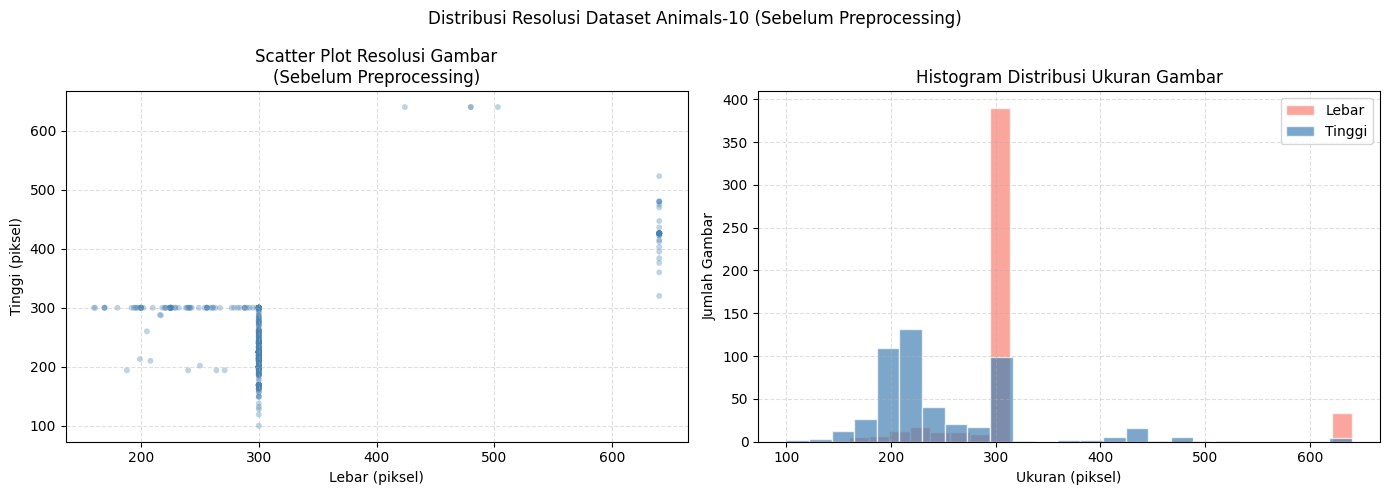

In [5]:
# Kumpulkan semua path gambar
all_paths = [
    p for p in glob(os.path.join(DATA_DIR, '*', '*'))
    if p.lower().endswith(('.jpg', '.jpeg', '.png'))
]
print(f'Total gambar valid: {len(all_paths):,}')

# Sampel 500 gambar untuk analisis resolusi
sample_paths = random.sample(all_paths, min(500, len(all_paths)))

widths, heights = [], []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception:
        pass

# Statistik
print('\n=== Statistik Resolusi Gambar (Sampel 500) ===')
print(f'Lebar  : Min={min(widths)}px | Max={max(widths)}px | Unik={len(set(widths))} nilai')
print(f'Tinggi : Min={min(heights)}px | Max={max(heights)}px | Unik={len(set(heights))} nilai')
print(f'Kombinasi resolusi unik: {len(set(zip(widths, heights)))}')

# Plot distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(widths, heights, alpha=0.35, color='steelblue', s=18, edgecolors='none')
axes[0].set_xlabel('Lebar (piksel)')
axes[0].set_ylabel('Tinggi (piksel)')
axes[0].set_title('Scatter Plot Resolusi Gambar\n(Sebelum Preprocessing)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(widths,  bins=25, color='salmon',    alpha=0.7, label='Lebar',  edgecolor='white')
axes[1].hist(heights, bins=25, color='steelblue', alpha=0.7, label='Tinggi', edgecolor='white')
axes[1].set_xlabel('Ukuran (piksel)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_title('Histogram Distribusi Ukuran Gambar')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribusi Resolusi Dataset Animals-10 (Sebelum Preprocessing)', fontsize=12)
plt.tight_layout()
plt.show()

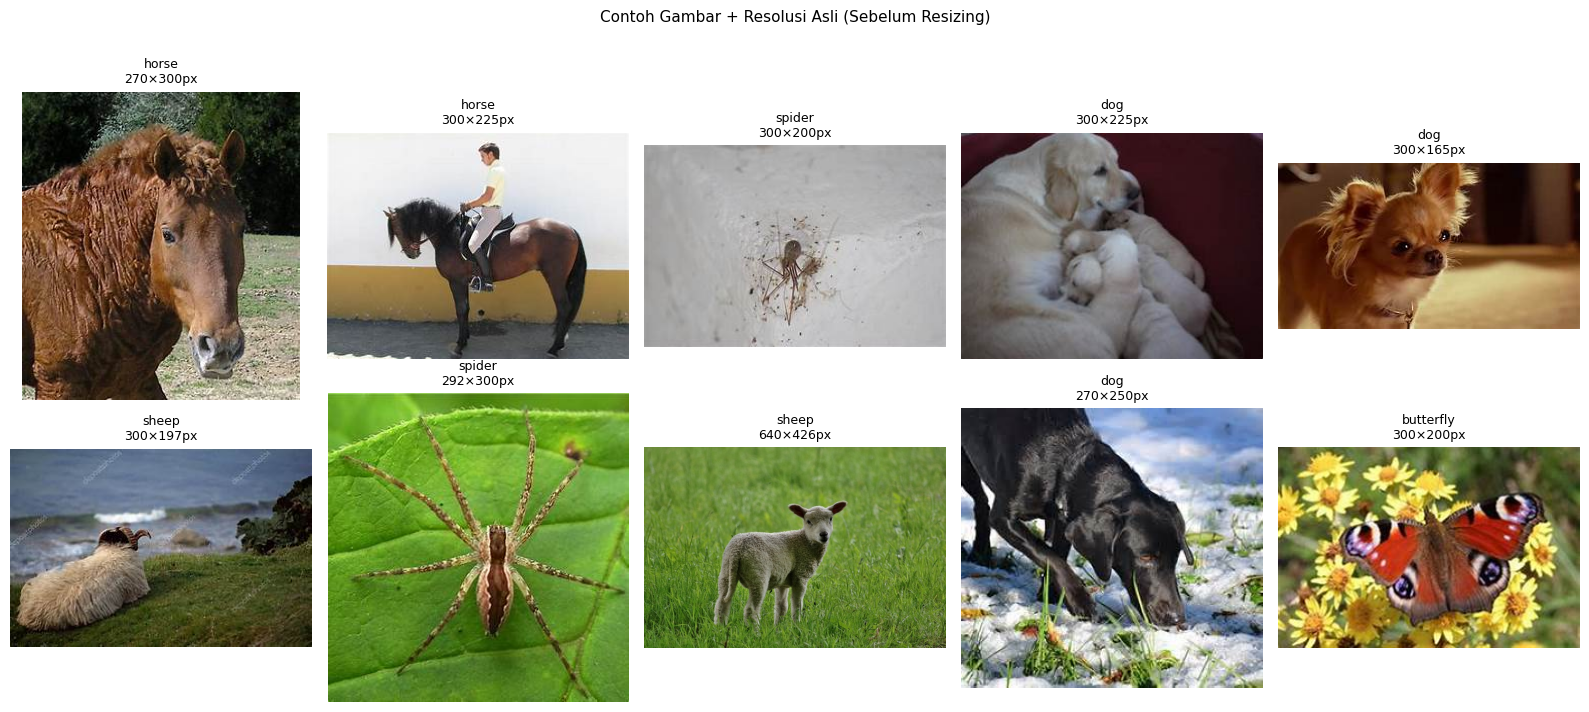

In [6]:
# Tampilkan 10 gambar sampel beserta resolusi aslinya
sample_display = random.sample(all_paths, 10)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, img_path in enumerate(sample_display):
    with Image.open(img_path) as img:
        w, h = img.size
        img_rgb = img.convert('RGB')
    label_name = os.path.basename(os.path.dirname(img_path))
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'{label_name}\n{w}×{h}px', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Contoh Gambar + Resolusi Asli (Sebelum Resizing)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Data Preprocessing

#### Split Dataset

Seluruh data dibagi menjadi **train (70%)**, **validation (15%)**, dan **test (15%)** menggunakan `train_test_split` dengan stratifikasi agar proporsi tiap kelas merata.

In [7]:
RANDOM_STATE = 42
IMG_HEIGHT   = 224   # MobileNetV2 optimal di 224×224
IMG_WIDTH    = 224
BATCH_SIZE   = 32
NUM_CLASSES  = 9 # Changed from 10 to 9 to match actual number of classes

# Buat DataFrame
filepaths = [
    p for p in glob(os.path.join(DATA_DIR, '*', '*'))
    if p.lower().endswith(('.jpg', '.jpeg', '.png'))
]
labels = [os.path.basename(os.path.dirname(p)) for p in filepaths]

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(f'Total gambar : {len(df):,}')
print(f'Total kelas  : {df["label"].nunique()}')
print('\nDistribusi kelas:')
print(df['label'].value_counts())

# Split 70 / 15 / 15
df_train, df_temp = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=RANDOM_STATE
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, stratify=df_temp['label'], random_state=RANDOM_STATE
)

print(f'\nTrain : {len(df_train):,} gambar')
print(f'Val   : {len(df_val):,} gambar')
print(f'Test  : {len(df_test):,} gambar')

Total gambar : 23,081
Total kelas  : 9

Distribusi kelas:
label
dog          4863
spider       4821
horse        2623
butterfly    2112
cow          1866
squirrel     1862
sheep        1820
cat          1668
elephant     1446
Name: count, dtype: int64

Train : 16,156 gambar
Val   : 3,462 gambar
Test  : 3,463 gambar


In [8]:
# Augmentasi agresif untuk train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Hanya normalisasi untuk val & test
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train,
    x_col='filepath', y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val,
    x_col='filepath', y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test,
    x_col='filepath', y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Mapping kelas:', train_generator.class_indices)

Found 16156 validated image filenames belonging to 9 classes.
Found 3462 validated image filenames belonging to 9 classes.
Found 3463 validated image filenames belonging to 9 classes.
Mapping kelas: {'butterfly': 0, 'cat': 1, 'cow': 2, 'dog': 3, 'elephant': 4, 'horse': 5, 'sheep': 6, 'spider': 7, 'squirrel': 8}


## Modelling

Arsitektur menggunakan **Transfer Learning dengan MobileNetV2** sebagai backbone (pretrained ImageNet, layer beku), dikombinasikan dengan custom classifier di atasnya. Lapisan `Conv2D`, `MaxPooling2D`, dan `Sequential` tetap digunakan pada custom head untuk memenuhi kriteria submission.

Training dilakukan dalam **2 tahap**:
1. **Fase 1** — Hanya train custom head (base model dibekukan)
2. **Fase 2** — Fine-tuning: buka 30 layer terakhir MobileNetV2 dengan LR sangat kecil

In [9]:
# Get the correct number of classes from the generator
NUM_CLASSES = len(train_generator.class_indices)
print("NUM_CLASSES dari generator:", NUM_CLASSES)

base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)

x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Dropout(0.3)(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Dropout(0.3)(x)

x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Ensure output layer matches the 9 classes found in the generator
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Output model shape:", model.output_shape)
print("Number of classes in train_generator:", len(train_generator.class_indices))

# Verification assertions
assert len(train_generator.class_indices) == len(val_generator.class_indices), "Train and Val class count mismatch"
assert model.output_shape[-1] == NUM_CLASSES, f"Model output {model.output_shape[-1]} does not match NUM_CLASSES {NUM_CLASSES}"

NUM_CLASSES dari generator: 9
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Output model shape: (None, 9)
Number of classes in train_generator: 9


In [10]:
# FASE 1 — Train hanya custom head (base model dibekukan)
print('FASE 1: Training Custom Head')
print(f'Layer yang di-train: {sum(1 for l in model.layers if l.trainable)}')

callbacks_fase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_fase1.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history_fase1 = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_fase1
)

print(f'\nFase 1 selesai.')
print(f'Val Accuracy terbaik: {max(history_fase1.history["val_accuracy"]):.4f}')

FASE 1: Training Custom Head
Layer yang di-train: 17
Epoch 1/15
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6670 - loss: 1.0694
Epoch 1: val_accuracy improved from None to 0.93472, saving model to best_model_fase1.keras

Epoch 1: finished saving model to best_model_fase1.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 296s 528ms/step - accuracy: 0.7722 - loss: 0.7201 - val_accuracy: 0.9347 - val_loss: 0.2123 - learning_rate: 0.0010
Epoch 2/15
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.8550 - loss: 0.4656
Epoch 2: val_accuracy improved from 0.93472 to 0.93905, saving model to best_model_fase1.keras

Epoch 2: finished saving model to best_model_fase1.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 232s 459ms/step - accuracy: 0.8570 - loss: 0.4568 - val_accuracy: 0.9391 - val_loss: 0.1953 - learning_rate: 0.0010
Epoch 3/15
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8702 - loss: 0.3948
Epoch 3: val_accuracy improved from 0.93905 to 0.94223, saving model to best_model_fase1.k

In [11]:
# FASE 2 — Fine-tuning: buka 30 layer terakhir MobileNetV2
print('FASE 2: Fine-tuning MobileNetV2')

# Buka 30 layer terakhir base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f'Layer yang di-train sekarang: {trainable_count}')

# Kompilasi ulang dengan LR sangat kecil
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_final.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history_fase2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_fase2
)

print(f'\nFase 2 selesai.')
print(f'Val Accuracy terbaik: {max(history_fase2.history["val_accuracy"]):.4f}')

FASE 2: Fine-tuning MobileNetV2
Layer yang di-train sekarang: 18
Epoch 1/30
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8869 - loss: 0.3517
Epoch 1: val_accuracy improved from None to 0.95263, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 270s 490ms/step - accuracy: 0.8943 - loss: 0.3318 - val_accuracy: 0.9526 - val_loss: 0.1562 - learning_rate: 1.0000e-04
Epoch 2/30
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9170 - loss: 0.2693
Epoch 2: val_accuracy improved from 0.95263 to 0.95350, saving model to best_model_final.keras

Epoch 2: finished saving model to best_model_final.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 231s 457ms/step - accuracy: 0.9169 - loss: 0.2677 - val_accuracy: 0.9535 - val_loss: 0.1541 - learning_rate: 1.0000e-04
Epoch 3/30
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9237 - loss: 0.2416
Epoch 3: val_accuracy improved from 0.95350 to 0.95985, saving model t

## Evaluasi dan Visualisasi

In [12]:
# Gabungkan history Fase 1 + Fase 2
acc      = history_fase1.history['accuracy']      + history_fase2.history['accuracy']
val_acc  = history_fase1.history['val_accuracy']  + history_fase2.history['val_accuracy']
loss     = history_fase1.history['loss']          + history_fase2.history['loss']
val_loss = history_fase1.history['val_loss']      + history_fase2.history['val_loss']

# Ringkasan performa
print(' Ringkasan Performa ')
print(f'Training Accuracy terbaik   : {max(acc):.4f}')
print(f'Validation Accuracy terbaik : {max(val_acc):.4f}')

# Evaluasi di test set
print('\n Evaluasi di Test Set ')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

=== Ringkasan Performa ===
Training Accuracy terbaik   : 0.9792
Validation Accuracy terbaik : 0.9653

=== Evaluasi di Test Set ===
109/109 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9677 - loss: 0.1180
Test Accuracy : 0.9677
Test Loss     : 0.1180


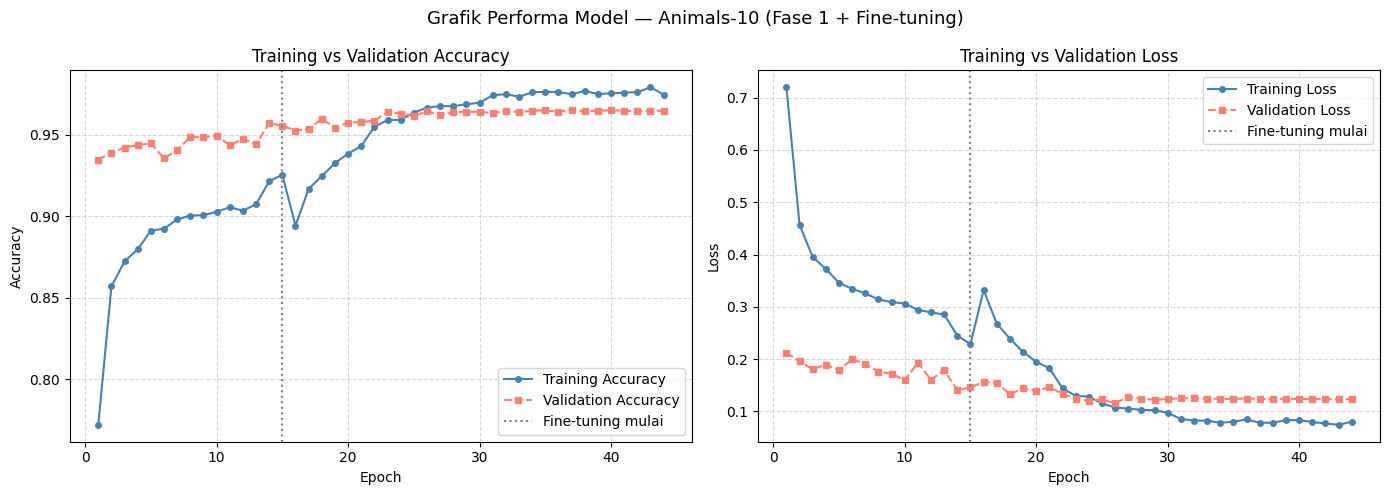

In [13]:
epochs_range = range(1, len(acc) + 1)
split_epoch  = len(history_fase1.history['accuracy'])  # batas fase 1 dan 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi
axes[0].plot(epochs_range, acc,     'o-',  label='Training Accuracy',   color='steelblue', markersize=4)
axes[0].plot(epochs_range, val_acc, 's--', label='Validation Accuracy', color='salmon',    markersize=4)
axes[0].axvline(x=split_epoch, color='gray', linestyle=':', linewidth=1.5, label='Fine-tuning mulai')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Loss
axes[1].plot(epochs_range, loss,     'o-',  label='Training Loss',   color='steelblue', markersize=4)
axes[1].plot(epochs_range, val_loss, 's--', label='Validation Loss', color='salmon',    markersize=4)
axes[1].axvline(x=split_epoch, color='gray', linestyle=':', linewidth=1.5, label='Fine-tuning mulai')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Grafik Performa Model — Animals-10 (Fase 1 + Fine-tuning)', fontsize=13)
plt.tight_layout()
plt.show()

109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step
= Classification Report =
              precision    recall  f1-score   support

   butterfly       0.98      0.99      0.98       317
         cat       0.98      0.94      0.96       250
         cow       0.94      0.95      0.94       280
         dog       0.97      0.95      0.96       730
    elephant       0.93      0.98      0.95       217
       horse       0.94      0.98      0.96       394
       sheep       0.97      0.94      0.95       273
      spider       0.99      0.99      0.99       723
    squirrel       0.98      0.98      0.98       279

    accuracy                           0.97      3463
   macro avg       0.96      0.97      0.96      3463
weighted avg       0.97      0.97      0.97      3463



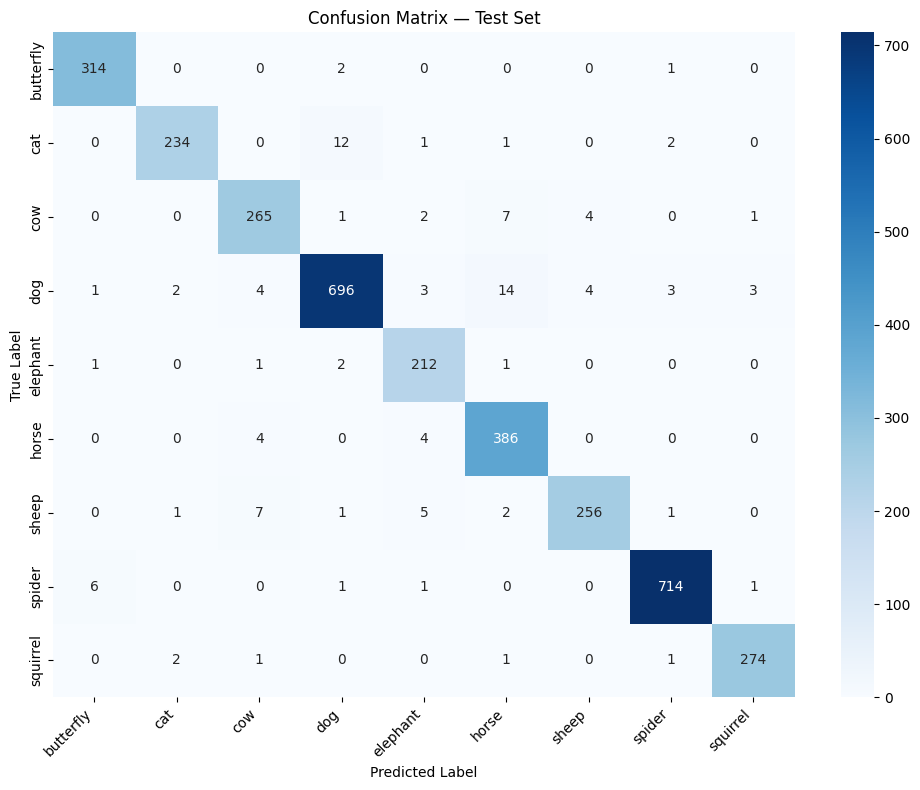

In [14]:
# Prediksi di test set
test_generator.reset()
y_pred_probs   = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = test_generator.classes

idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
class_names  = [idx_to_class[i] for i in range(NUM_CLASSES)]

# Classification Report
print('= Classification Report =')
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Konversi Model

Model disimpan dalam tiga format:
- **SavedModel** — format standar TensorFlow
- **TFLite** — untuk inferensi di perangkat mobile/edge
- **TensorFlow.js** — untuk inferensi di browser/web

In [15]:
# 1. SavedModel
saved_model_dir = 'saved_model'
os.makedirs(saved_model_dir, exist_ok=True)
model.export(saved_model_dir)
print('SavedModel selesai:', saved_model_dir)

# 2. TFLite
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print('TFLite selesai: model.tflite')

# 3. Label.txt
with open('label.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')
print('Label selesai: label.txt')

# 4. TensorFlow.js
tfjs_dir = 'tfjs_model'
os.makedirs(tfjs_dir, exist_ok=True)
tfjs.converters.convert_tf_saved_model(saved_model_dir, tfjs_dir)
print('TFJS selesai:', tfjs_dir)

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  132446552733456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552731728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552735376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552732688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552734992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132446552735568

## Inference (Optional)

Uji model menggunakan gambar hewan dari luar dataset yang diupload secara manual.

SavedModel berhasil di-load.

Upload 1 gambar hewan (jpg/png):


Saving 3.jpg to 3.jpg

=== Hasil Inference ===
File       : 3.jpg
Prediksi   : cat
Confidence : 0.9998 (99.98%)


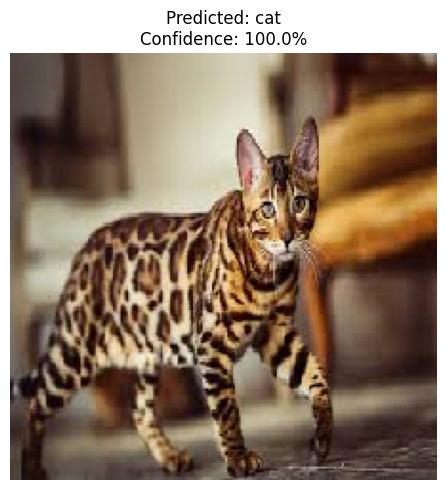

In [19]:
# Load SavedModel
inference_model = tf.keras.layers.TFSMLayer(saved_model_dir, call_endpoint='serve')
print('SavedModel berhasil di-load.')

# Upload gambar dari luar dataset
print('\nUpload 1 gambar hewan (jpg/png):')
uploaded = files.upload()

if uploaded:
    image_path = list(uploaded.keys())[0]

    # Preprocessing — sama persis seperti saat training
    img       = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Prediksi
    pred_probs = inference_model(img_input)
    pred_idx   = int(np.argmax(pred_probs[0]))
    pred_label = idx_to_class[pred_idx]
    confidence = float(np.max(pred_probs[0]))

    print(f'\n=== Hasil Inference ===')
    print(f'File       : {image_path}')
    print(f'Prediksi   : {pred_label}')
    print(f'Confidence : {confidence:.4f} ({confidence*100:.2f}%)')

    # Tampilkan gambar + prediksi
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted: {pred_label}\nConfidence: {confidence*100:.1f}%', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada gambar yang diupload.')